# DDXPlus Matched-Evidence And Integrated Comparison

This notebook evaluates the current sequential line against four direct-diagnosis references on the exact same cases:

- initial-evidence one-shot baseline
- sequential final answer
- matched-evidence one-shot prediction using exactly the fields revealed by the sequential policy
- partial-evidence-trained matched one-shot comparator when notebook `10` has been run
- full-evidence one-shot comparator

The matched-evidence comparator is intentionally a bag-of-evidence analysis: it uses demographics, initial evidence, and the set of revealed evidence fields, but it does not use turn order, hidden labels, hidden differentials, or unrevealed evidence. If notebook `10` has produced a partial-evidence one-shot model, this notebook uses it for the matched comparator. Otherwise it falls back to the older full-evidence-model-on-partial-state comparator. The full-evidence comparator is an evaluation ceiling only and is never used inside the live sequential policy.

In [1]:
from __future__ import annotations

import ast
import json
import os
import zipfile
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import f1_score
from torch import nn

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 30)

ROOT = next(
    (candidate for candidate in [Path.cwd(), Path.cwd().parent] if (candidate / "scripts" / "download_ddxplus.py").exists()),
    Path.cwd(),
)
DATASET_ENV_VAR = "DDXPLUS_DATASET_DIR"
DEFAULT_DATASET_DIR = ROOT / "dataset"
LEGACY_DATASET_DIR = ROOT / ".data" / "ddxplus" / "22687585"
DATASET_DIR = (
    Path(os.environ[DATASET_ENV_VAR]).expanduser()
    if os.environ.get(DATASET_ENV_VAR)
    else DEFAULT_DATASET_DIR
    if DEFAULT_DATASET_DIR.exists()
    else LEGACY_DATASET_DIR
    if LEGACY_DATASET_DIR.exists()
    else DEFAULT_DATASET_DIR
)

SPLIT_NAME = "test"
SEQUENTIAL_RUN_NAME = "single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1"
SEQUENTIAL_ARTIFACT_FAMILY = "cost_sensitive"  # cost_sensitive | refined
FULL_EVIDENCE_RUN_NAME = None  # set explicitly after running notebook 07 if needed
PARTIAL_EVIDENCE_RUN_NAME = None  # set explicitly after running notebook 10 if needed
USE_PARTIAL_EVIDENCE_MATCHED_MODEL = True
OUTPUT_VERSION = "matched_integrated_partial_policy_v1"

ARTIFACT_ROOT = ROOT / "artifacts" / "integrated_comparisons"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = None

print("Project root:", ROOT)
print("Dataset dir :", DATASET_DIR)

Project root: /Users/bilalawan/claw/assignments/baseline_model
Dataset dir : /Users/bilalawan/claw/assignments/baseline_model/dataset


## Data And Model Helpers

In [2]:
REQUIRED_FILES = [
    "release_evidences.json",
    "release_conditions.json",
    "release_train_patients.zip",
    "release_validate_patients.zip",
    "release_test_patients.zip",
]
SPLIT_TO_FILENAME = {
    "train": "release_train_patients.zip",
    "validate": "release_validate_patients.zip",
    "test": "release_test_patients.zip",
}


def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def ensure_dataset_present(dataset_dir: Path) -> dict[str, Path]:
    dataset_dir = dataset_dir.expanduser().resolve()
    paths = {name: dataset_dir / name for name in REQUIRED_FILES}
    missing = [name for name, path in paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing dataset files in {dataset_dir}: {', '.join(missing)}")
    invalid_zips = [name for name, path in paths.items() if path.suffix == ".zip" and not zipfile.is_zipfile(path)]
    if invalid_zips:
        raise ValueError(f"Invalid zip files in {dataset_dir}: {', '.join(invalid_zips)}")
    return paths


def load_patient_split(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as archive:
        members = [name for name in archive.namelist() if not name.endswith("/")]
        file_name = next((name for name in members if name.endswith(".csv")), None) or members[0]
        with archive.open(file_name) as handle:
            return pd.read_csv(handle)


def attach_split_metadata(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    enriched = frame.copy()
    enriched["source_row_index"] = np.arange(len(enriched), dtype=int)
    enriched["split"] = split_name
    enriched["case_id"] = enriched["source_row_index"].map(lambda idx: f"{split_name}:{idx}")
    return enriched


def safe_parse_list(raw: Any) -> list[Any]:
    if isinstance(raw, list):
        return raw
    if raw is None:
        return []
    if isinstance(raw, float) and np.isnan(raw):
        return []
    if isinstance(raw, str):
        try:
            return json.loads(raw)
        except Exception:
            return ast.literal_eval(raw)
    return list(raw)


def parse_evidence_token(token: str) -> tuple[str, str | None]:
    if "_@_" not in token:
        return token, None
    return tuple(token.split("_@_", 1))


def encode_age(age: int) -> int:
    if age < 1:
        return 0
    if age <= 4:
        return 1
    if age <= 14:
        return 2
    if age <= 29:
        return 3
    if age <= 44:
        return 4
    if age <= 59:
        return 5
    if age <= 74:
        return 6
    return 7


def encode_sex(sex: str) -> int:
    if sex == "M":
        return 0
    if sex == "F":
        return 1
    raise ValueError(f"Unexpected sex value: {sex}")


@dataclass
class ObservationSchema:
    root_ids: list[str]
    slot_slices: dict[str, tuple[int, int]]
    data_types: dict[str, str]
    possible_values: dict[str, list[str]]
    default_values: dict[str, str | None]
    categorical_integer_roots: set[str]
    feature_names: list[str]

    @classmethod
    def from_metadata(cls, evidence_metadata: dict[str, dict[str, Any]]) -> "ObservationSchema":
        root_ids = list(evidence_metadata.keys())
        slot_slices = {}
        data_types = {}
        possible_values = {}
        default_values = {}
        categorical_integer_roots = set()
        feature_names = [f"age_bin_{idx}" for idx in range(8)] + ["sex_M", "sex_F"]
        cursor = 10
        for root_id in root_ids:
            meta = evidence_metadata[root_id]
            data_type = meta.get("data_type", "B")
            raw_values = meta.get("possible-values", [])
            values = [str(value) for value in raw_values]
            default_value = meta.get("default_value")
            default_value = None if default_value is None else str(default_value)
            data_types[root_id] = data_type
            possible_values[root_id] = values
            default_values[root_id] = default_value
            if data_type == "B":
                slot_slices[root_id] = (cursor, cursor + 1)
                feature_names.append(root_id)
                cursor += 1
            elif data_type == "C":
                if raw_values and not isinstance(raw_values[0], str):
                    categorical_integer_roots.add(root_id)
                    slot_slices[root_id] = (cursor, cursor + 1)
                    feature_names.append(root_id)
                    cursor += 1
                else:
                    slot_slices[root_id] = (cursor, cursor + len(values))
                    feature_names.extend(f"{root_id}__{value}" for value in values)
                    cursor += len(values)
            elif data_type == "M":
                slot_slices[root_id] = (cursor, cursor + len(values))
                feature_names.extend(f"{root_id}__{value}" for value in values)
                cursor += len(values)
            else:
                raise ValueError(f"Unsupported evidence type {data_type} for {root_id}")
        return cls(root_ids, slot_slices, data_types, possible_values, default_values, categorical_integer_roots, feature_names)

    @property
    def feature_size(self) -> int:
        return len(self.feature_names)

    def initial_state(self, age: int, sex: str) -> np.ndarray:
        state = np.zeros(self.feature_size, dtype=np.float32)
        state[encode_age(int(age))] = 1.0
        state[8 + encode_sex(sex)] = 1.0
        return state

    def apply_root_observation(self, state: np.ndarray, root_id: str, present_values: list[str] | None = None) -> np.ndarray:
        values = [str(value) for value in (present_values or [])]
        data_type = self.data_types[root_id]
        start, end = self.slot_slices[root_id]
        default_value = self.default_values[root_id]
        if data_type == "B":
            state[start] = 1.0 if values else -1.0
            return state
        if root_id in self.categorical_integer_roots:
            chosen = values[0] if values else default_value
            if chosen is None:
                state[start] = 0.0
                return state
            idx = self.possible_values[root_id].index(str(chosen))
            state[start] = float((idx + 1) / max(1, len(self.possible_values[root_id])))
            return state
        state[start:end] = -1.0
        selected_values = values if values else ([default_value] if default_value is not None else [])
        for value in selected_values:
            idx = self.possible_values[root_id].index(str(value))
            state[start + idx] = 1.0
        return state


class DirectDiagnosisMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: list[int], num_classes: int, dropout: float = 0.0):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(previous_dim, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            previous_dim = hidden_size
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Linear(previous_dim, num_classes)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.backbone(features))

## Discover Artifacts

In [3]:
def discover_selected_initial_one_shot_dir() -> Path:
    selected_path = ROOT / "artifacts" / "one_shot" / "selected_model.json"
    payload = load_json(selected_path)
    return Path(payload["selected_artifact_dir"])


def discover_full_evidence_dir() -> Path | None:
    root = ROOT / "artifacts" / "one_shot_full_evidence"
    if FULL_EVIDENCE_RUN_NAME:
        candidate = root / FULL_EVIDENCE_RUN_NAME
        return candidate if candidate.exists() else None
    selected = root / "selected_model.json"
    if selected.exists():
        payload = load_json(selected)
        return Path(payload["selected_artifact_dir"])
    candidates = sorted([path for path in root.glob("*") if (path / "best_model.pt").exists()], key=lambda path: path.stat().st_mtime, reverse=True)
    return candidates[0] if candidates else None


def discover_partial_evidence_dir() -> Path | None:
    root = ROOT / "artifacts" / "one_shot_partial_evidence"
    if not USE_PARTIAL_EVIDENCE_MATCHED_MODEL:
        return None
    if PARTIAL_EVIDENCE_RUN_NAME:
        candidate = root / PARTIAL_EVIDENCE_RUN_NAME
        return candidate if (candidate / "best_model.pt").exists() else None
    selected = root / "selected_model.json"
    if selected.exists():
        payload = load_json(selected)
        candidate = Path(payload["selected_artifact_dir"])
        return candidate if (candidate / "best_model.pt").exists() else None
    candidates = sorted([path for path in root.glob("*") if (path / "best_model.pt").exists()], key=lambda path: path.stat().st_mtime, reverse=True)
    return candidates[0] if candidates else None


def discover_sequential_run_dir() -> Path:
    if SEQUENTIAL_ARTIFACT_FAMILY == "cost_sensitive":
        root = ROOT / "artifacts" / "sequential_single_agent_cost_sensitive"
    elif SEQUENTIAL_ARTIFACT_FAMILY == "refined":
        root = ROOT / "artifacts" / "sequential_single_agent_refined"
    else:
        raise ValueError(f"Unknown sequential artifact family: {SEQUENTIAL_ARTIFACT_FAMILY}")
    if SEQUENTIAL_RUN_NAME:
        candidate = root / SEQUENTIAL_RUN_NAME
        if not candidate.exists():
            raise FileNotFoundError(candidate)
        return candidate
    candidates = sorted([path for path in root.glob("*") if path.is_dir() and (path / "resolved_run_config.json").exists()], key=lambda path: path.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No sequential runs found under {root}")
    return candidates[0]


initial_one_shot_dir = discover_selected_initial_one_shot_dir()
full_evidence_dir = discover_full_evidence_dir()
partial_evidence_dir = discover_partial_evidence_dir()
sequential_run_dir = discover_sequential_run_dir()
comparison_name = f"{sequential_run_dir.name}__{OUTPUT_VERSION}"
COMPARISON_DIR = ARTIFACT_ROOT / comparison_name
FIGURE_DIR = COMPARISON_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Initial one-shot dir:", initial_one_shot_dir)
print("Full-evidence dir   :", full_evidence_dir)
print("Partial-evidence dir:", partial_evidence_dir)
print("Sequential run dir  :", sequential_run_dir)
print("Comparison dir      :", COMPARISON_DIR)

Initial one-shot dir: /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot/basd_pathology_full
Full-evidence dir   : /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_full_evidence/full_evidence_pathology_full
Partial-evidence dir: /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_partial_evidence/partial_evidence_one_shot_final_policy_masked_v2
Sequential run dir  : /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_cost_sensitive/single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1
Comparison dir      : /Users/bilalawan/claw/assignments/baseline_model/artifacts/integrated_comparisons/single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1__matched_integrated_partial_policy_v1


## Load Models, Cases, And Sequential Reveals

In [4]:
dataset_paths = ensure_dataset_present(DATASET_DIR)
evidences = load_json(dataset_paths["release_evidences.json"])
conditions = load_json(dataset_paths["release_conditions.json"])
label_names = list(conditions.keys())
pathology_to_index = {label: idx for idx, label in enumerate(label_names)}
schema = ObservationSchema.from_metadata(evidences)
raw_split = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME[SPLIT_NAME]]), SPLIT_NAME)
split_lookup = {str(row.case_id): row._asdict() for row in raw_split.itertuples(index=False)}

initial_predictions = pd.read_csv(initial_one_shot_dir / "predictions.csv")
initial_predictions = initial_predictions[initial_predictions["split"] == SPLIT_NAME].copy()
full_predictions_existing = None
if full_evidence_dir is not None and (full_evidence_dir / "predictions.csv").exists():
    full_predictions_existing = pd.read_csv(full_evidence_dir / "predictions.csv")
    full_predictions_existing = full_predictions_existing[full_predictions_existing["split"] == SPLIT_NAME].copy()


def iter_condition_dirs(run_dir: Path) -> list[tuple[str, float | int, Path]]:
    lambda_dirs = []
    for path in sorted(run_dir.glob("lambda_*")):
        if (path / "predictions.csv").exists():
            raw = path.name.replace("lambda_", "").replace("p", ".")
            lambda_dirs.append(("lambda", float(raw), path))
    if lambda_dirs:
        return lambda_dirs
    budget_dirs = []
    for path in sorted(run_dir.glob("budget_*")):
        if (path / "predictions.csv").exists():
            budget_dirs.append(("budget", int(path.name.replace("budget_", "")), path))
    if budget_dirs:
        return budget_dirs
    raise FileNotFoundError(f"No lambda_* or budget_* prediction directories found in {run_dir}")


def extract_revealed_roots_from_trace(trace_row: dict[str, Any], initial_evidence: str) -> dict[str, list[str]]:
    initial_root, initial_value = parse_evidence_token(str(initial_evidence))
    revealed = {initial_root: [initial_value] if initial_value is not None else ["present"]}
    for step in trace_row.get("trace", []):
        payload = step.get("reveal_payload") or {}
        root_id = payload.get("root_evidence_id")
        if not root_id:
            continue
        values = payload.get("revealed_values") or []
        revealed[str(root_id)] = [str(value) for value in values]
    return revealed


def load_trace_lookup(condition_dir: Path) -> dict[str, dict[str, Any]]:
    trace_path = condition_dir / "traces.jsonl"
    lookup = {}
    if trace_path.exists():
        with trace_path.open("r", encoding="utf-8") as handle:
            for line in handle:
                row = json.loads(line)
                lookup[str(row["case_id"])] = row
    return lookup

condition_dirs = iter_condition_dirs(sequential_run_dir)
print("Conditions found:", [(kind, value) for kind, value, _ in condition_dirs])

Conditions found: [('lambda', 0.1), ('lambda', 0.22), ('lambda', 0.35), ('lambda', 0.5), ('lambda', 0.75)]


## Direct Classifier Prediction Helpers

In [5]:
def load_direct_model(model_dir: Path) -> tuple[nn.Module, list[str], dict[str, Any]]:
    checkpoint = torch.load(model_dir / "best_model.pt", map_location="cpu")
    resolved = checkpoint.get("resolved_run_config", {})
    labels = list(checkpoint.get("label_names", label_names))
    hidden_sizes = list(resolved.get("hidden_sizes", [2048, 2048, 2048]))
    dropout = float(resolved.get("dropout", 0.0))
    model = DirectDiagnosisMLP(schema.feature_size, hidden_sizes, len(labels), dropout=dropout)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, labels, resolved


def row_evidence_by_root(row: dict[str, Any]) -> dict[str, list[str]]:
    evidence_by_root = {}
    for token in safe_parse_list(row["EVIDENCES"]):
        root_id, value = parse_evidence_token(str(token))
        evidence_by_root.setdefault(root_id, [])
        if value is None:
            evidence_by_root[root_id].append("present")
        else:
            evidence_by_root[root_id].append(str(value))
    return evidence_by_root


def encode_state_from_roots(row: dict[str, Any], revealed_roots: dict[str, list[str]], full_evidence: bool = False) -> np.ndarray:
    state = schema.initial_state(int(row["AGE"]), str(row["SEX"]))
    evidence_by_root = row_evidence_by_root(row)
    if full_evidence:
        root_iter = schema.root_ids
    else:
        root_iter = sorted(revealed_roots.keys())
    for root_id in root_iter:
        if full_evidence:
            values = evidence_by_root.get(root_id, [])
        else:
            values = revealed_roots.get(root_id, [])
            if values == ["present"]:
                values = evidence_by_root.get(root_id, ["present"])
        schema.apply_root_observation(state, root_id, values)
    return state


def predict_features(model: nn.Module, features: np.ndarray, labels: list[str]) -> tuple[list[str], list[list[str]], list[float]]:
    with torch.no_grad():
        logits = model(torch.tensor(features, dtype=torch.float32))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
    top5 = np.argsort(probs, axis=1)[:, ::-1][:, :5]
    pred_indices = np.argmax(probs, axis=1)
    predictions = [labels[idx] for idx in pred_indices]
    ranked = [[labels[idx] for idx in row] for row in top5]
    confidences = [float(probs[row_idx, pred_idx]) for row_idx, pred_idx in enumerate(pred_indices)]
    return predictions, ranked, confidences


def top_k_accuracy(true_labels: list[str], ranked_lists: list[list[str]], k: int) -> float:
    return float(np.mean([true in ranked[:k] for true, ranked in zip(true_labels, ranked_lists)])) if true_labels else 0.0


def metrics_from_predictions(true_labels: list[str], pred_labels: list[str], ranked_lists: list[list[str]]) -> dict[str, float]:
    return {
        "accuracy": float(np.mean([true == pred for true, pred in zip(true_labels, pred_labels)])) if true_labels else 0.0,
        "top3_accuracy": top_k_accuracy(true_labels, ranked_lists, 3),
        "top5_accuracy": top_k_accuracy(true_labels, ranked_lists, 5),
        "macro_f1": float(f1_score(true_labels, pred_labels, average="macro")) if true_labels else 0.0,
    }

full_model = None
full_model_labels = None
partial_model = None
partial_model_labels = None
matched_model = None
matched_model_labels = None
matched_model_source = None

if full_evidence_dir is not None and (full_evidence_dir / "best_model.pt").exists():
    full_model, full_model_labels, full_model_config = load_direct_model(full_evidence_dir)
    print("Loaded full-evidence model:", full_evidence_dir)
else:
    print("Full-evidence model not found. Run notebook 07 before using full direct predictions.")

if partial_evidence_dir is not None and (partial_evidence_dir / "best_model.pt").exists():
    partial_model, partial_model_labels, partial_model_config = load_direct_model(partial_evidence_dir)
    matched_model = partial_model
    matched_model_labels = partial_model_labels
    matched_model_source = "partial_evidence_one_shot"
    print("Loaded partial-evidence matched model:", partial_evidence_dir)
elif full_model is not None:
    matched_model = full_model
    matched_model_labels = full_model_labels
    matched_model_source = "full_evidence_model_fallback"
    print("Partial-evidence model not found. Falling back to full-evidence model for matched partial states.")
else:
    print("No matched direct model found. Run notebook 10 or notebook 07 first.")

Loaded full-evidence model: /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_full_evidence/full_evidence_pathology_full
Loaded partial-evidence matched model: /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_partial_evidence/partial_evidence_one_shot_final_policy_masked_v2


/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_45964/1127003506.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_dir / "best_mod

## Build Matched-Evidence Comparisons

In [6]:
comparison_rows = []
summary_rows = []

for condition_kind, condition_value, condition_dir in condition_dirs:
    seq_predictions = pd.read_csv(condition_dir / "predictions.csv")
    trace_lookup = load_trace_lookup(condition_dir)
    case_ids = seq_predictions["case_id"].astype(str).tolist()
    initial_subset = initial_predictions[initial_predictions["case_id"].isin(case_ids)].copy()
    initial_lookup = initial_subset.set_index("case_id").to_dict(orient="index")
    full_lookup = {}
    if full_predictions_existing is not None:
        full_lookup = full_predictions_existing[full_predictions_existing["case_id"].isin(case_ids)].set_index("case_id").to_dict(orient="index")

    matched_features = []
    full_features = []
    true_labels = []
    matched_revealed_counts = []
    for seq_row in seq_predictions.itertuples(index=False):
        case_id = str(seq_row.case_id)
        raw_row = split_lookup[case_id]
        trace_row = trace_lookup.get(case_id, {})
        revealed_roots = extract_revealed_roots_from_trace(trace_row, getattr(seq_row, "initial_evidence", raw_row["INITIAL_EVIDENCE"]))
        matched_features.append(encode_state_from_roots(raw_row, revealed_roots, full_evidence=False))
        full_features.append(encode_state_from_roots(raw_row, revealed_roots, full_evidence=True))
        true_labels.append(str(raw_row["PATHOLOGY"]))
        matched_revealed_counts.append(len(revealed_roots))

    if matched_model is not None:
        matched_pred, matched_ranked, matched_conf = predict_features(matched_model, np.vstack(matched_features), matched_model_labels)
    else:
        matched_pred = [None] * len(case_ids)
        matched_ranked = [[] for _ in case_ids]
        matched_conf = [np.nan] * len(case_ids)

    if full_model is not None:
        full_pred_model, full_ranked_model, full_conf_model = predict_features(full_model, np.vstack(full_features), full_model_labels)
    else:
        full_pred_model = [None] * len(case_ids)
        full_ranked_model = [[] for _ in case_ids]
        full_conf_model = [np.nan] * len(case_ids)

    for idx, seq_row in enumerate(seq_predictions.itertuples(index=False)):
        case_id = str(seq_row.case_id)
        initial_row = initial_lookup.get(case_id, {})
        full_row = full_lookup.get(case_id, {})
        full_pred = str(full_row.get("pred_pathology", full_pred_model[idx])) if full_row else full_pred_model[idx]
        full_ranked = safe_parse_list(full_row.get("top5_predictions", json.dumps(full_ranked_model[idx]))) if full_row else full_ranked_model[idx]
        comparison_rows.append({
            "condition_kind": condition_kind,
            "condition_value": condition_value,
            "case_id": case_id,
            "true_pathology": true_labels[idx],
            "num_requests": int(seq_row.num_requests),
            "revealed_root_count": int(matched_revealed_counts[idx]),
            "initial_pred": initial_row.get("pred_pathology"),
            "initial_ranked": initial_row.get("top5_predictions"),
            "initial_correct": bool(initial_row.get("pred_pathology") == true_labels[idx]),
            "sequential_pred": str(seq_row.predicted_pathology),
            "sequential_ranked": str(seq_row.ranked_differential),
            "sequential_correct": bool(seq_row.predicted_pathology == true_labels[idx]),
            "matched_model_source": matched_model_source,
            "matched_pred": matched_pred[idx],
            "matched_ranked": json.dumps(matched_ranked[idx]),
            "matched_confidence": matched_conf[idx],
            "matched_correct": bool(matched_pred[idx] == true_labels[idx]) if matched_pred[idx] is not None else np.nan,
            "full_pred": full_pred,
            "full_ranked": json.dumps(full_ranked) if isinstance(full_ranked, list) else full_ranked,
            "full_confidence": full_conf_model[idx],
            "full_correct": bool(full_pred == true_labels[idx]) if full_pred is not None else np.nan,
        })

comparison_frame = pd.DataFrame(comparison_rows)
comparison_frame.to_csv(COMPARISON_DIR / "paired_case_results.csv", index=False)

def summarize_condition(frame: pd.DataFrame, condition_kind: str, condition_value: float | int) -> dict[str, Any]:
    true_labels = frame["true_pathology"].astype(str).tolist()
    initial_ranked = frame["initial_ranked"].map(safe_parse_list).tolist()
    seq_ranked = frame["sequential_ranked"].map(safe_parse_list).tolist()
    matched_ranked = frame["matched_ranked"].map(safe_parse_list).tolist()
    full_ranked = frame["full_ranked"].map(safe_parse_list).tolist()
    initial_acc = float(frame["initial_correct"].mean())
    seq_acc = float(frame["sequential_correct"].mean())
    matched_acc = float(frame["matched_correct"].mean()) if frame["matched_correct"].notna().any() else np.nan
    full_acc = float(frame["full_correct"].mean()) if frame["full_correct"].notna().any() else np.nan
    denom = full_acc - initial_acc if np.isfinite(full_acc) else np.nan
    def gain_fraction(acc: float) -> float:
        if not np.isfinite(denom) or abs(denom) < 1e-9:
            return np.nan
        return float((acc - initial_acc) / denom)
    return {
        "condition_kind": condition_kind,
        "condition_value": condition_value,
        "num_cases": int(len(frame)),
        "mean_requests": float(frame["num_requests"].mean()),
        "initial_accuracy": initial_acc,
        "initial_top3": top_k_accuracy(true_labels, initial_ranked, 3),
        "initial_top5": top_k_accuracy(true_labels, initial_ranked, 5),
        "sequential_accuracy": seq_acc,
        "sequential_top3": top_k_accuracy(true_labels, seq_ranked, 3),
        "sequential_top5": top_k_accuracy(true_labels, seq_ranked, 5),
        "sequential_macro_f1": float(f1_score(true_labels, frame["sequential_pred"].astype(str).tolist(), average="macro")),
        "matched_accuracy": matched_acc,
        "matched_top3": top_k_accuracy(true_labels, matched_ranked, 3) if frame["matched_correct"].notna().any() else np.nan,
        "matched_top5": top_k_accuracy(true_labels, matched_ranked, 5) if frame["matched_correct"].notna().any() else np.nan,
        "matched_macro_f1": float(f1_score(true_labels, frame["matched_pred"].astype(str).tolist(), average="macro")) if frame["matched_correct"].notna().any() else np.nan,
        "full_accuracy": full_acc,
        "full_top3": top_k_accuracy(true_labels, full_ranked, 3) if frame["full_correct"].notna().any() else np.nan,
        "full_top5": top_k_accuracy(true_labels, full_ranked, 5) if frame["full_correct"].notna().any() else np.nan,
        "full_macro_f1": float(f1_score(true_labels, frame["full_pred"].astype(str).tolist(), average="macro")) if frame["full_correct"].notna().any() else np.nan,
        "sequential_fraction_full_evidence_gain_recovered": gain_fraction(seq_acc),
        "matched_fraction_full_evidence_gain_recovered": gain_fraction(matched_acc),
        "sequential_gap_to_full": float(full_acc - seq_acc) if np.isfinite(full_acc) else np.nan,
        "matched_gap_to_full": float(full_acc - matched_acc) if np.isfinite(full_acc) and np.isfinite(matched_acc) else np.nan,
        "matched_minus_sequential_accuracy": float(matched_acc - seq_acc) if np.isfinite(matched_acc) else np.nan,
    }

for (condition_kind, condition_value), group in comparison_frame.groupby(["condition_kind", "condition_value"], sort=True):
    summary_rows.append(summarize_condition(group, condition_kind, condition_value))
summary_frame = pd.DataFrame(summary_rows).sort_values(["condition_kind", "condition_value"]).reset_index(drop=True)
summary_frame.to_csv(COMPARISON_DIR / "integrated_summary.csv", index=False)
with (COMPARISON_DIR / "resolved_comparison_config.json").open("w", encoding="utf-8") as handle:
    json.dump({
        "sequential_run_dir": str(sequential_run_dir),
        "initial_one_shot_dir": str(initial_one_shot_dir),
        "full_evidence_dir": str(full_evidence_dir) if full_evidence_dir is not None else None,
        "partial_evidence_dir": str(partial_evidence_dir) if partial_evidence_dir is not None else None,
        "matched_model_source": matched_model_source,
        "fairness_rule": "Full-evidence predictions are evaluation-only and are not used by the live sequential policy. Partial-evidence matched model is trained only from official train/validation rows and policy-shaped masks, not test labels.",
    }, handle, indent=2)

display(summary_frame)
summary_frame

,condition_kind,condition_value,num_cases,mean_requests,initial_accuracy,initial_top3,initial_top5,sequential_accuracy,sequential_top3,sequential_top5,...,matched_macro_f1,full_accuracy,full_top3,full_top5,full_macro_f1,sequential_fraction_full_evidence_gain_recovered,matched_fraction_full_evidence_gain_recovered,sequential_gap_to_full,matched_gap_to_full,matched_minus_sequential_accuracy
0,lambda,0.10,24,13.041667,0.333333,0.541667,0.625,0.916667,0.916667,0.916667,...,0.777778,1.0,1.0,1.0,1.0,0.8750,0.8125,0.083333,0.125000,-0.041667
1,lambda,0.22,24,10.666667,0.333333,0.541667,0.625,0.875000,0.875000,0.916667,...,0.777778,1.0,1.0,1.0,1.0,0.8125,0.8125,0.125000,0.125000,0.000000
2,lambda,0.35,24,8.333333,0.333333,0.541667,0.625,0.875000,0.875000,0.875000,...,0.756410,1.0,1.0,1.0,1.0,0.8125,0.7500,0.125000,0.166667,-0.041667
3,lambda,0.50,24,2.208333,0.333333,0.541667,0.625,0.416667,0.625000,0.750000,...,0.359524,1.0,1.0,1.0,1.0,0.1250,0.1875,0.583333,0.541667,0.041667
4,lambda,0.75,24,1.041667,0.333333,0.541667,0.625,0.375000,0.583333,0.708333,...,0.293040,1.0,1.0,1.0,1.0,0.0625,0.0625,0.625000,0.625000,0.000000


,condition_kind,condition_value,num_cases,mean_requests,initial_accuracy,initial_top3,initial_top5,sequential_accuracy,sequential_top3,sequential_top5,...,matched_macro_f1,full_accuracy,full_top3,full_top5,full_macro_f1,sequential_fraction_full_evidence_gain_recovered,matched_fraction_full_evidence_gain_recovered,sequential_gap_to_full,matched_gap_to_full,matched_minus_sequential_accuracy
0,lambda,0.10,24,13.041667,0.333333,0.541667,0.625,0.916667,0.916667,0.916667,...,0.777778,1.0,1.0,1.0,1.0,0.8750,0.8125,0.083333,0.125000,-0.041667
1,lambda,0.22,24,10.666667,0.333333,0.541667,0.625,0.875000,0.875000,0.916667,...,0.777778,1.0,1.0,1.0,1.0,0.8125,0.8125,0.125000,0.125000,0.000000
2,lambda,0.35,24,8.333333,0.333333,0.541667,0.625,0.875000,0.875000,0.875000,...,0.756410,1.0,1.0,1.0,1.0,0.8125,0.7500,0.125000,0.166667,-0.041667
3,lambda,0.50,24,2.208333,0.333333,0.541667,0.625,0.416667,0.625000,0.750000,...,0.359524,1.0,1.0,1.0,1.0,0.1250,0.1875,0.583333,0.541667,0.041667
4,lambda,0.75,24,1.041667,0.333333,0.541667,0.625,0.375000,0.583333,0.708333,...,0.293040,1.0,1.0,1.0,1.0,0.0625,0.0625,0.625000,0.625000,0.000000


## Plots

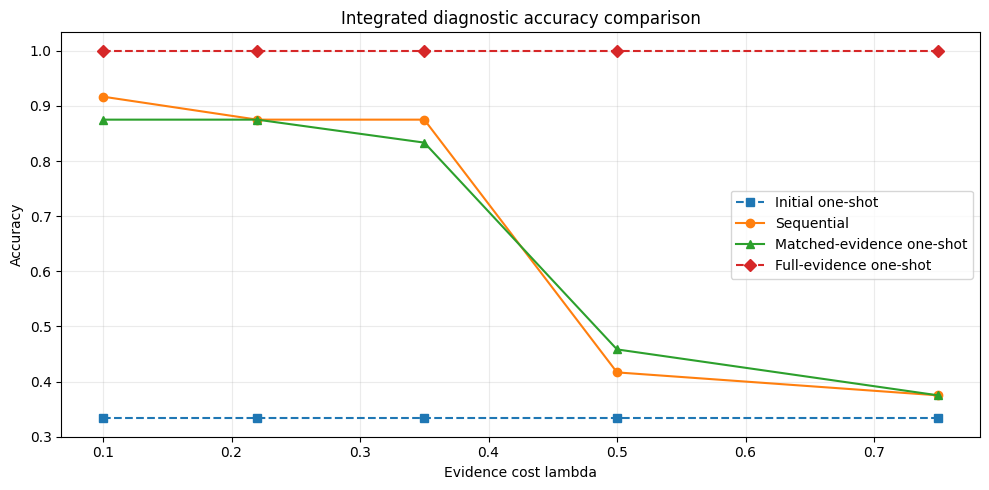

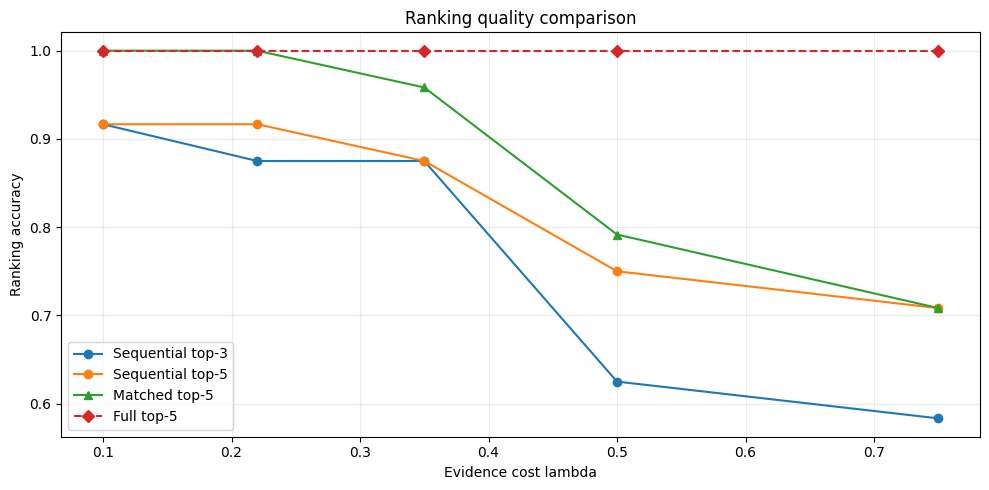

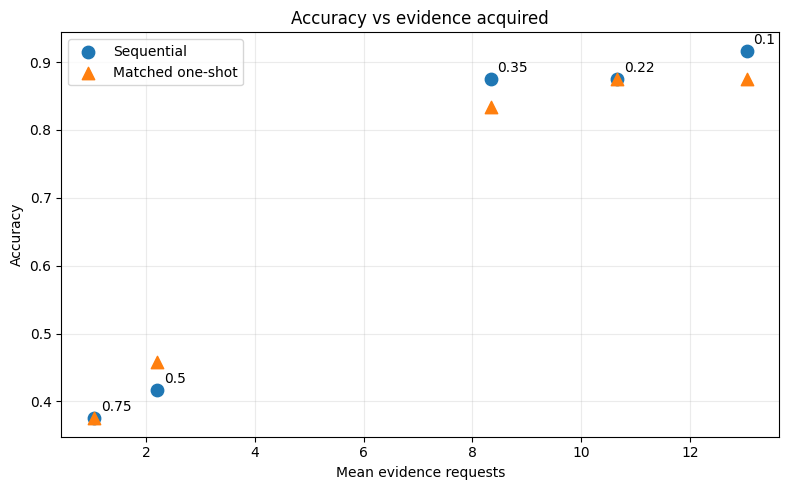

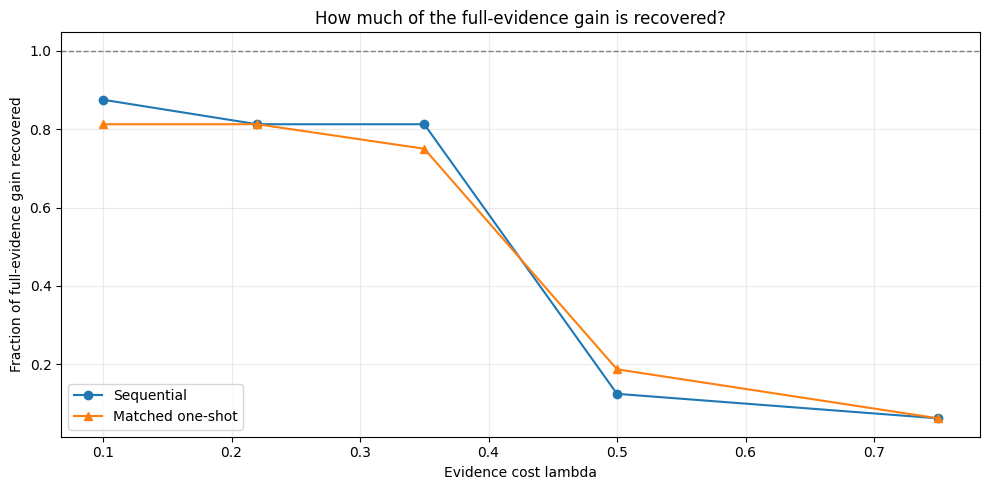

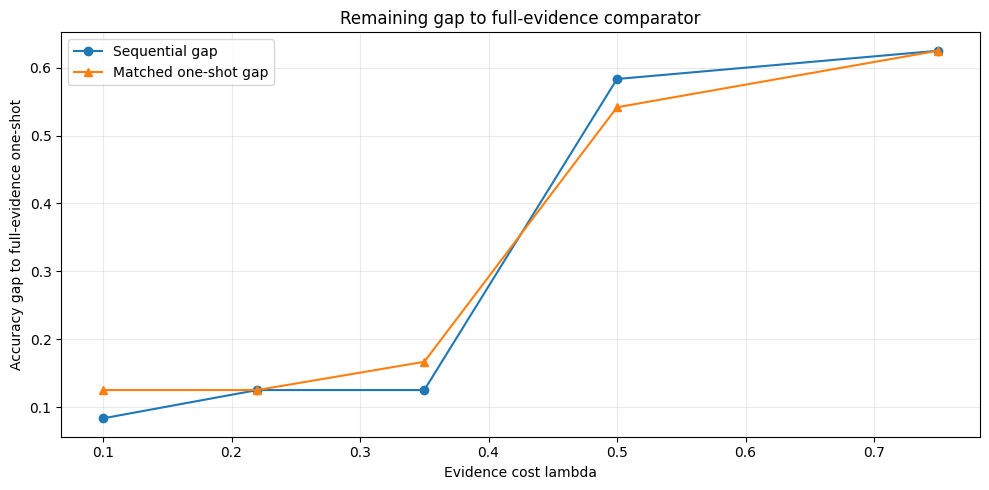

,condition_kind,condition_value,num_cases,mean_requests,initial_accuracy,initial_top3,initial_top5,sequential_accuracy,sequential_top3,sequential_top5,...,matched_macro_f1,full_accuracy,full_top3,full_top5,full_macro_f1,sequential_fraction_full_evidence_gain_recovered,matched_fraction_full_evidence_gain_recovered,sequential_gap_to_full,matched_gap_to_full,matched_minus_sequential_accuracy
0,lambda,0.10,24,13.041667,0.333333,0.541667,0.625,0.916667,0.916667,0.916667,...,0.777778,1.0,1.0,1.0,1.0,0.8750,0.8125,0.083333,0.125000,-0.041667
1,lambda,0.22,24,10.666667,0.333333,0.541667,0.625,0.875000,0.875000,0.916667,...,0.777778,1.0,1.0,1.0,1.0,0.8125,0.8125,0.125000,0.125000,0.000000
2,lambda,0.35,24,8.333333,0.333333,0.541667,0.625,0.875000,0.875000,0.875000,...,0.756410,1.0,1.0,1.0,1.0,0.8125,0.7500,0.125000,0.166667,-0.041667
3,lambda,0.50,24,2.208333,0.333333,0.541667,0.625,0.416667,0.625000,0.750000,...,0.359524,1.0,1.0,1.0,1.0,0.1250,0.1875,0.583333,0.541667,0.041667
4,lambda,0.75,24,1.041667,0.333333,0.541667,0.625,0.375000,0.583333,0.708333,...,0.293040,1.0,1.0,1.0,1.0,0.0625,0.0625,0.625000,0.625000,0.000000


In [7]:
x_col = "condition_value"
x_label = "Evidence cost lambda" if summary_frame["condition_kind"].iloc[0] == "lambda" else "Request budget"

plt.figure(figsize=(10, 5))
plt.plot(summary_frame[x_col], summary_frame["initial_accuracy"], linestyle="--", marker="s", label="Initial one-shot")
plt.plot(summary_frame[x_col], summary_frame["sequential_accuracy"], marker="o", label="Sequential")
if summary_frame["matched_accuracy"].notna().any():
    plt.plot(summary_frame[x_col], summary_frame["matched_accuracy"], marker="^", label="Matched-evidence one-shot")
if summary_frame["full_accuracy"].notna().any():
    plt.plot(summary_frame[x_col], summary_frame["full_accuracy"], linestyle="--", marker="D", label="Full-evidence one-shot")
plt.xlabel(x_label)
plt.ylabel("Accuracy")
plt.title("Integrated diagnostic accuracy comparison")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "integrated_accuracy_comparison.png", dpi=180)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(summary_frame[x_col], summary_frame["sequential_top3"], marker="o", label="Sequential top-3")
plt.plot(summary_frame[x_col], summary_frame["sequential_top5"], marker="o", label="Sequential top-5")
if summary_frame["matched_top5"].notna().any():
    plt.plot(summary_frame[x_col], summary_frame["matched_top5"], marker="^", label="Matched top-5")
if summary_frame["full_top5"].notna().any():
    plt.plot(summary_frame[x_col], summary_frame["full_top5"], marker="D", linestyle="--", label="Full top-5")
plt.xlabel(x_label)
plt.ylabel("Ranking accuracy")
plt.title("Ranking quality comparison")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "integrated_ranking_comparison.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(summary_frame["mean_requests"], summary_frame["sequential_accuracy"], s=80, label="Sequential")
if summary_frame["matched_accuracy"].notna().any():
    plt.scatter(summary_frame["mean_requests"], summary_frame["matched_accuracy"], s=80, marker="^", label="Matched one-shot")
for row in summary_frame.itertuples(index=False):
    plt.annotate(str(row.condition_value), (row.mean_requests, row.sequential_accuracy), textcoords="offset points", xytext=(5, 5))
plt.xlabel("Mean evidence requests")
plt.ylabel("Accuracy")
plt.title("Accuracy vs evidence acquired")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "accuracy_vs_mean_requests_integrated.png", dpi=180)
plt.show()

if summary_frame["sequential_fraction_full_evidence_gain_recovered"].notna().any():
    plt.figure(figsize=(10, 5))
    plt.plot(summary_frame[x_col], summary_frame["sequential_fraction_full_evidence_gain_recovered"], marker="o", label="Sequential")
    plt.plot(summary_frame[x_col], summary_frame["matched_fraction_full_evidence_gain_recovered"], marker="^", label="Matched one-shot")
    plt.axhline(1.0, linestyle="--", color="gray", linewidth=1)
    plt.xlabel(x_label)
    plt.ylabel("Fraction of full-evidence gain recovered")
    plt.title("How much of the full-evidence gain is recovered?")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "full_evidence_gain_recovered.png", dpi=180)
    plt.show()

if summary_frame["sequential_gap_to_full"].notna().any():
    plt.figure(figsize=(10, 5))
    plt.plot(summary_frame[x_col], summary_frame["sequential_gap_to_full"], marker="o", label="Sequential gap")
    plt.plot(summary_frame[x_col], summary_frame["matched_gap_to_full"], marker="^", label="Matched one-shot gap")
    plt.xlabel(x_label)
    plt.ylabel("Accuracy gap to full-evidence one-shot")
    plt.title("Remaining gap to full-evidence comparator")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "remaining_gap_to_full_evidence.png", dpi=180)
    plt.show()

summary_frame

## Interpretation Notes

Use this notebook to answer two separate questions. First, does targeted sequential evidence acquisition recover a meaningful fraction of the gap between initial evidence and full evidence? Second, given the exact same evidence acquired by the sequential policy, does the LLM final answer outperform a direct bag-of-evidence classifier?

If matched-evidence one-shot beats the sequential final answer, that is not a failure. It suggests the sequential system may be more useful as a question-selection controller, with a direct classifier handling the final diagnosis.